# Denoising Diffusion Probabilistic Models

## 0. Prelim

First, we have a set of $N$ data samples $\mathcal X=\{x_i|i\in \mathbb Z_N \}$, assumed uniquely sampled from an unknown distribution $x_i\sim p_{\text{data}}$.

The MNIST dataset is a good example. In this case, $x_i\in\mathbb R^{784}$.

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])

import os
os.makedirs('../0.Data/', exist_ok=True)
train_data = datasets.MNIST('../0.Data/', train=True, download=True, transform=transform)
test_data = datasets.MNIST('../0.Data/', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

print(f"Loaded {len(train_data)} train, {len(test_data)} test samples")

/data/envs/SML_env/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /data/envs/SML_env/lib/python3.10/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Loaded 60000 train, 10000 test samples


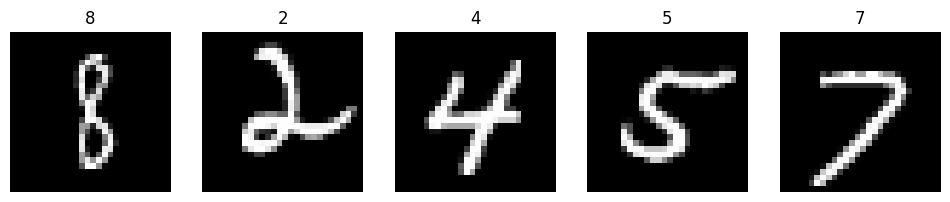

Batch shape: torch.Size([128, 784])
Single image shape: torch.Size([784])


In [2]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    img = images[i].view(28, 28)  
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'{labels[i]}')
    axes[i].axis('off')
plt.show()

print(f"Batch shape: {images.shape}")
print(f"Single image shape: {images[0].shape}")

## 1. Modelling

Unlike the VAE architecture, DDPMs use a *Fixed* encoder layer, gradually noising the input data from $x_0$ to Gaussian Noise $x_L$. For such process, a linear interpolation encoder is used as below.
$$p(x_i|x_{i-1}):=\mathcal N(x_i;\sqrt{1-\beta^2_i}x_{i-1},\beta^2_i\mathbf I),\quad\text{where }\beta_i\in(0,1)$$
The increasing noise scheduler $\{\beta_i\}_{i=1}^L$ denotes a predetermined encoding process. Such process can easily be defined iteratively as below.
$$x_i=\alpha_ix_{i-1}+\beta_i\epsilon_i,\quad\text{where }\alpha_i=\sqrt{1-\beta_i^2},\space\epsilon_i\sim\mathcal N(0,\mathbf I)$$

Now with this deterministic iterative process per time step, we can denote a closed form distribution at time step $i$ with respect to $x_0$ as below.
$$\mathbb E(x_i)=\alpha_i\mathbb E(x_{i-1})+\beta_i\mathbb E(\epsilon_i)=\Pi_{k=1}^i\alpha_k\space x_0$$
$$\text{Var}(x_i)=(1-\beta_i^2)\text{Var}(x_{i-1})+\beta_i^2=\left[\Pi_{k=1}^i(1-\beta_k^2)\right]\text{Var}(x_0)+\Sigma_{j=1}^i\beta_j^2\Pi_{k=j+1}^i(1-\beta_k^2)=1-\Pi_{k=1}^i\alpha_k^2$$
$$p_i(x_i|x_0)=\mathcal N(x_i;\bar{\alpha}_ix_0,(1-\bar{\alpha}_i^2)\mathbf I),\quad\text{where }\bar\alpha_i :=\Pi_{k=1}^i\sqrt{1-\beta_k^2}=\Pi_{k=1}^i\alpha_k$$
Now, we can sample from an arbitrary time step with an initial data point $x_0$. With an increasing noise scheduler, it is trivial that the prior distribution at time step $L$ must be $p_{\text{prior}}:=\mathcal N(0,\mathbf I)$.

OUr goal now is to approximate the reverse transition kernel from the prior distribution, $p(x_{i-1}|x_i)$. To do this, we would train a network $\phi$ to approximate it via a KL Divergence.
$$\mathbb E_{p_i(x_i)}\left[\mathcal D_{\text{KL}}(p(x_{i-1}|x_i)|p_\phi(x_{i-1}|x_i))\right]$$
However the target distribution is intractable.
$$p(x_{i-1}|x_i)=p(x_i|x_{i-1})\frac{p_{i-1}(x_{i-1})}{p_i(x_i)},\quad\text{where }p_i(x_i)=\int p_i(x_i|x_0)p_{\text{data}}(x_0)dx_0$$
This intractability is solved rather easily, with our presummably uniformly sampled dataset $\mathcal X=\{ \hat x_i\}_{i=1}^D$. Our posterior probability now becomes
$$p(x_{i-1}|x_i,\hat x)=p(x_i|x_{i-1})\frac{p_{i-1}(x_{i-1}|\hat x)}{p_i(x_i|\hat x)}$$
Due to Markovian properties, it is trivial that $p(x_i|x_{i-1},x)=p(x_i|x_{i-1})$ and is a gaussian. Now we get an equivarence between marginal and conditional distributions.
$$\mathbb E_{p_i(x_i)}\mathcal D_{\text{KL}}(p(x_{i-1}|x_i)||p_\phi(x_{i-1}|x_i))=\mathbb E_{p_{\text{data}(\hat x)}}\mathbb E_{p(x_i|\hat x)}\mathcal D_{\text{KL}}(p(x_{i-1}|x_i,\hat x)||p_\phi(x_{i-1}|x_i))+C$$
The reverse conditional transition kernel $p(x_{i-1}|x_i,\hat x)$ has a closed from calculated from $p(x_{i-1}|x_i,\hat x)=p(x_i|x_{i-1})\frac{p_{i-1}(x_{i-1}|\hat x)}{p_i(x_i|\hat x)}$
$$p(x_{i-1}|x_i,\hat x)=\mathcal N(x_{i-1};\frac{\bar \alpha_{i-1}\beta_i^2}{1-\bar\alpha_i^2}\hat x+\frac{(1-\bar\alpha_{i-1}^2)\alpha_i}{1-\bar\alpha_i^2}x_i,\frac{1-\bar\alpha_{i-1}^2}{1-\bar\alpha_i^2}\beta_i^2\mathbf I)$$

Now, our Trainable reverse transition kernel can be modeled with a gaussian as below
$$p_\phi(x_{i-1}|x_i):=\mathcal N(x_{i-1};\mu_\phi(x_i,i),\sigma^2(i)\mathbf I),\quad\text{where }\mu_\phi(\cdot,i):\mathbb R^D\to\mathbb R^D,\space\sigma^2(i)\in\mathbb R_+$$
So the overall loss function with a data sample $x_0$ is
$$\mathcal L_{\text{diffusion}}(x_0,\phi):=\Sigma_{i=1}^L\mathbb E_{p(x_i|x_0)}\left[\mathcal D_{\text{KL}}(p(x_{i-1}|x_i,x_0)||p_\phi(x_{i-1}|x_i))\right]=\Sigma_{i=1}^L\frac{1}{2\sigma^2(i)}||\mu_\phi(x_i,i)-\frac{\bar \alpha_{i-1}\beta_i^2}{1-\bar\alpha_i^2}\hat x+\frac{(1-\bar\alpha_{i-1}^2)\alpha_i}{1-\bar\alpha_i^2}x_i||^2_2+C$$
Averaging over the dataset $\mathcal X$ gives the final loss function of the DDPM architecture.

### Practical Loss

There are 2 types of practical predictions
1. $\epsilon$ prediction
2. $x$ prediction

Let's denote $\mathbb E_{p(x_{i-1}|x_i,x_0)}x_{i-1}$ as $\mu(x_i,x_0,i)=\frac{\bar \alpha_{i-1}\beta_i^2}{1-\bar\alpha_i^2} x_0-\frac{(1-\bar\alpha_{i-1}^2)\alpha_i}{1-\bar\alpha_i^2}x_i$.
We know that $x_i$ follows a gaussian distribution denoted below
$$x_i=\bar\alpha_ix_0+\sqrt{1-\bar\alpha_i^2}\epsilon,\quad\text{where }\epsilon\sim\mathcal N(0,\mathbf I)$$
$$\text{Therefore, }\mu(x_i,x_0,i)=\frac{1}{\alpha_i}(x_i-\frac{1-\alpha_i^2}{\sqrt{1-\bar\alpha_i^2}}\epsilon)$$
Now our training goal of $\mu_\phi(x_i,i)$ can be rewritten as follow.
$$\mu_\phi(x_i,i)=\frac{1}{\alpha_i}(x_i-\frac{1-\alpha_i^2}{\sqrt{1-\bar\alpha_i^2}}\epsilon_\phi(x_i,i))$$
$$||\mu_\phi(x_i,i)-\mu(x_i,x_0,i)||^2_2\space\alpha\space||\epsilon_\phi(x_i,i)-\epsilon||^2_2=\mathbb E_{\epsilon\sim\mathcal N(0,\mathbf I)}||\epsilon_\phi(\bar\alpha_ix_0+\sqrt{1-\bar\alpha^2_i}\epsilon, i)-\epsilon||^2_2$$
Now the final loss is 
$$\mathbb E_i\mathbb E_{x\sim p_{\text{data}}}\mathbb E_{\epsilon\sim\mathcal N(0,\mathbf I)}||\epsilon_\phi(\bar\alpha_ix+\sqrt{1-\bar\alpha^2_i}\epsilon, i)-\epsilon||^2_2$$

A similar simplification may be through a parameterization of the initial sample $x_0$.
$$\mu(x_i,x_0,i)=\frac{\bar \alpha_{i-1}\beta_i^2}{1-\bar\alpha_i^2} x_\phi(x_i,i)-\frac{(1-\bar\alpha_{i-1}^2)\alpha_i}{1-\bar\alpha_i^2}x_i$$
$$\mathcal L:=\mathbb E_i\mathbb E_{x\sim p_{\text{data}}}\mathbb E_{\epsilon\sim\mathcal N(0,\mathbf I)}||x_\phi(\bar\alpha_ix+\sqrt{1-\bar\alpha^2_i}\epsilon, i)-x||^2_2$$

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [4]:
class NoiseSchedule:
    def __init__(self, beta_start=0.0001, beta_end=0.02, n_timesteps=1000, device='cuda'):
        self.n_timesteps = n_timesteps
        self.device = device
        
        # Linear schedule for betas
        self.betas = torch.linspace(beta_start, beta_end, n_timesteps).to(device)
        self.alphas = 1 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)
        
        # Pre-compute values for diffusion q(x_t | x_0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - self.alphas_cumprod)
        
        # Pre-compute values for posterior q(x_{t-1} | x_t, x_0)
        self.posterior_variance = self.betas * (1 - self.alphas_cumprod_prev) / (1 - self.alphas_cumprod)
        self.posterior_log_variance = torch.log(torch.clamp(self.posterior_variance, min=1e-20))
        self.posterior_mean_coef1 = torch.sqrt(self.alphas_cumprod_prev) * self.betas / (1 - self.alphas_cumprod)
        self.posterior_mean_coef2 = torch.sqrt(self.alphas) * (1 - self.alphas_cumprod_prev) / (1 - self.alphas_cumprod)

In [5]:
class UNet(nn.Module):
    """Simple UNet for epsilon prediction"""
    def __init__(self, in_channels=1, out_channels=1, time_embedding_dim=64, hidden_dims=[32, 32, 64]):
        super().__init__()
        self.time_embedding_dim = time_embedding_dim
        
        # Time embedding MLP
        self.time_mlp = nn.Sequential(
            nn.Linear(time_embedding_dim, time_embedding_dim * 4),
            nn.SiLU(),
            nn.Linear(time_embedding_dim * 4, time_embedding_dim * 4)
        )
        
        # Encoder
        self.enc1 = self._make_block(in_channels, hidden_dims[0])
        self.enc2 = self._make_block(hidden_dims[0], hidden_dims[1])
        self.enc3 = self._make_block(hidden_dims[1], hidden_dims[2])
        
        # Bottleneck
        self.bottleneck = self._make_block(hidden_dims[2], hidden_dims[2])
        
        # Decoder with skip connections
        self.dec3 = self._make_block(hidden_dims[2] * 2, hidden_dims[1])
        self.dec2 = self._make_block(hidden_dims[1] * 2, hidden_dims[0])
        self.dec1 = self._make_block(hidden_dims[0] * 2, hidden_dims[0])
        
        # Final output
        self.final = nn.Conv2d(hidden_dims[0], out_channels, kernel_size=1)
        
        # Time projection layers for each level
        self.time_projs = nn.ModuleList([
            nn.Linear(time_embedding_dim * 4, hidden_dims[0]),
            nn.Linear(time_embedding_dim * 4, hidden_dims[1]),
            nn.Linear(time_embedding_dim * 4, hidden_dims[2])
        ])
    
    def _make_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    
    def get_time_embedding(self, t, channels):
        """Sinusoidal time embeddings"""
        inv_freq = 1.0 / (10000 ** (torch.arange(0, channels, 2, device=t.device) / channels))
        pos_enc_a = torch.sin(t.unsqueeze(1) * inv_freq)
        pos_enc_b = torch.cos(t.unsqueeze(1) * inv_freq)
        pos_enc = torch.cat([pos_enc_a, pos_enc_b], dim=1)
        return pos_enc
    
    def forward(self, x, t):
        # Get time embeddings
        t_emb = self.get_time_embedding(t, self.time_embedding_dim)
        t_emb = self.time_mlp(t_emb)
        
        # Encoder with time conditioning
        e1 = self.enc1(x)
        e1 = e1 + self.time_projs[0](t_emb)[:, :, None, None]
        
        e2 = self.enc2(F.max_pool2d(e1, 2))
        e2 = e2 + self.time_projs[1](t_emb)[:, :, None, None]
        
        e3 = self.enc3(F.max_pool2d(e2, 2))
        e3 = e3 + self.time_projs[2](t_emb)[:, :, None, None]
        
        # Bottleneck
        b = self.bottleneck(F.max_pool2d(e3, 2))
        
        # Decoder with skip connections
        d3 = self.dec3(torch.cat([F.interpolate(b, e3.shape[2:], mode='nearest'), e3], dim=1))
        d2 = self.dec2(torch.cat([F.interpolate(d3, e2.shape[2:], mode='nearest'), e2], dim=1))
        d1 = self.dec1(torch.cat([F.interpolate(d2, e1.shape[2:], mode='nearest'), e1], dim=1))
        
        # Output predicted noise
        out = self.final(d1)
        return out

In [6]:
class DDPM:
    def __init__(self, model, noise_schedule, device='cuda'):
        self.model = model
        self.noise_schedule = noise_schedule
        self.device = device
        self.n_timesteps = noise_schedule.n_timesteps
    
    def q_sample(self, x_0, t, noise=None):
        """Forward diffusion process: q(x_t | x_0)"""
        if noise is None:
            noise = torch.randn_like(x_0)
        
        sqrt_alphas_cumprod_t = self.noise_schedule.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t = self.noise_schedule.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        
        # x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * epsilon
        x_t = sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise
        return x_t, noise
    
    def p_mean_variance(self, x_t, t, predicted_noise):
        """Compute mean and variance for p(x_{t-1} | x_t)"""
        # Extract coefficients
        alpha_t = self.noise_schedule.alphas[t].view(-1, 1, 1, 1)
        alpha_bar_t = self.noise_schedule.alphas_cumprod[t].view(-1, 1, 1, 1)
        beta_t = self.noise_schedule.betas[t].view(-1, 1, 1, 1)
        
        # Predict x_0 from x_t and predicted noise
        x_0_pred = (x_t - torch.sqrt(1 - alpha_bar_t) * predicted_noise) / torch.sqrt(alpha_bar_t)
        x_0_pred = torch.clamp(x_0_pred, -1, 1)
        
        # Compute posterior mean
        posterior_mean = (torch.sqrt(alpha_t) * (1 - alpha_bar_t / alpha_t) * x_t + 
                         torch.sqrt(alpha_bar_t / alpha_t) * beta_t * x_0_pred) / (1 - alpha_bar_t)
        
        # Posterior variance (using fixed variance)
        posterior_variance = self.noise_schedule.posterior_variance[t].view(-1, 1, 1, 1)
        posterior_log_variance = self.noise_schedule.posterior_log_variance[t].view(-1, 1, 1, 1)
        
        return posterior_mean, posterior_variance, posterior_log_variance
    
    @torch.no_grad()
    def p_sample(self, x_t, t):
        """Sample from p(x_{t-1} | x_t)"""
        # Predict noise
        predicted_noise = self.model(x_t, t)
        
        # Get mean and variance
        mean, variance, log_variance = self.p_mean_variance(x_t, t, predicted_noise)
        
        # Sample
        noise = torch.randn_like(x_t) if t[0] > 0 else torch.zeros_like(x_t)
        x_t_minus_1 = mean + torch.exp(0.5 * log_variance) * noise
        
        return x_t_minus_1
    
    @torch.no_grad()
    def sample(self, batch_size, img_shape):
        """Generate samples from pure noise"""
        self.model.eval()
        
        # Start from pure noise
        x_t = torch.randn(batch_size, *img_shape).to(self.device)
        
        # Denoise step by step
        for i in tqdm(reversed(range(self.n_timesteps)), desc='Sampling', total=self.n_timesteps):
            t = torch.full((batch_size,), i, device=self.device, dtype=torch.long)
            x_t = self.p_sample(x_t, t)
        
        return x_t

In [7]:
class SimpleDiffusionLoss:
    """Simple L2 loss for epsilon prediction"""
    @staticmethod
    def compute(model, x_0, noise_schedule):
        batch_size = x_0.shape[0]
        device = x_0.device
        
        # Sample random timesteps
        t = torch.randint(0, noise_schedule.n_timesteps, (batch_size,), device=device)
        
        # Sample noise
        noise = torch.randn_like(x_0)
        
        # Get noisy image x_t
        x_t, _ = DDPM(model, noise_schedule).q_sample(x_0, t, noise)
        
        # Predict noise
        predicted_noise = model(x_t, t)
        
        # L2 loss between predicted and actual noise
        loss = F.mse_loss(predicted_noise, noise)
        
        return loss

# 2. Markdown

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

noise_schedule = NoiseSchedule(beta_start=0.0001, beta_end=0.02, n_timesteps=1000, device=device)
model = UNet(in_channels=1, out_channels=1).to(device)
ddpm = DDPM(model, noise_schedule, device=device)
criterion = SimpleDiffusionLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-4)

Using device: cuda


In [9]:
# Training loop
train_epochs = 100
for epoch in range(train_epochs):
    model.train()
    train_loss = 0
    
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        
        # Normalize to [-1, 1]
        data = (data * 2) - 1
        
        optimizer.zero_grad()
        loss = criterion.compute(model, data, noise_schedule)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    avg_loss = train_loss / len(train_loader)
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}, Average Loss: {avg_loss:.6f}')

/tmp/ipykernel_1290819/2282324114.py:21: UserWarning: Using a target size (torch.Size([128, 784])) that is different to the input size (torch.Size([128, 1, 128, 784])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(predicted_noise, noise)
/tmp/ipykernel_1290819/2282324114.py:21: UserWarning: Using a target size (torch.Size([96, 784])) that is different to the input size (torch.Size([96, 1, 96, 784])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(predicted_noise, noise)


KeyboardInterrupt: 

# 3. Inference

Generating 8 samples from noise...


Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 268.35it/s]


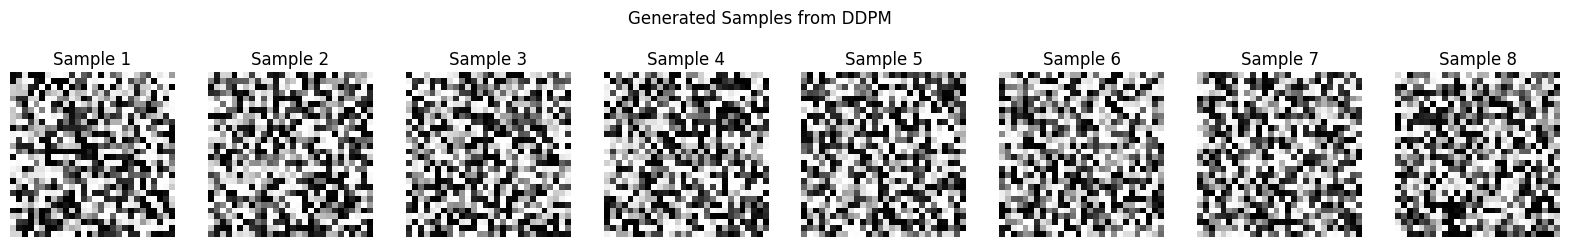

In [ ]:
# Generate samples
n_samples = 8
print(f"Generating {n_samples} samples from noise...")

samples = ddpm.sample(batch_size=n_samples, img_shape=(1, 28, 28))

# Denormalize from [-1, 1] to [0, 1]
samples = (samples + 1) / 2
samples = samples.clamp(0, 1)

# Visualize
fig, axes = plt.subplots(1, n_samples, figsize=(20, 3))
for i in range(n_samples):
    axes[i].imshow(samples[i, 0].cpu(), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'Sample {i+1}')
plt.suptitle('Generated Samples from DDPM')
plt.show()

Visualizing denoising process...


Denoising: 1000it [00:04, 245.02it/s]


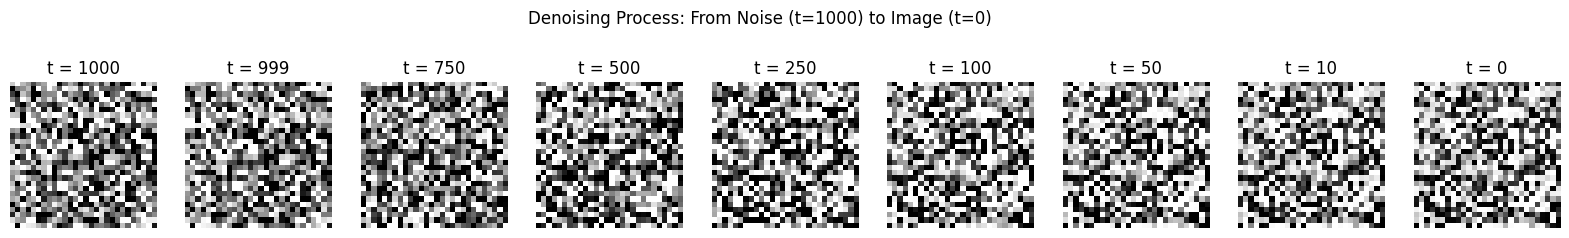

In [ ]:
# Visualize the denoising process
print("Visualizing denoising process...")

# Start from noise
x_t = torch.randn(1, 1, 28, 28).to(device)
intermediates = [x_t.cpu()]

# Save intermediate steps
steps_to_save = [999, 750, 500, 250, 100, 50, 10, 0]
current_x = x_t.clone()

for i in tqdm(reversed(range(noise_schedule.n_timesteps)), desc='Denoising'):
    t = torch.tensor([i]).to(device)
    current_x = ddpm.p_sample(current_x, t)
    
    if i in steps_to_save:
        intermediates.append(current_x.cpu())

# Plot
fig, axes = plt.subplots(1, len(intermediates), figsize=(20, 3))
for idx, (img, step) in enumerate(zip(intermediates, [1000] + steps_to_save)):
    img_show = (img[0, 0] + 1) / 2  # Denormalize
    axes[idx].imshow(img_show.clamp(0, 1), cmap='gray')
    axes[idx].axis('off')
    axes[idx].set_title(f't = {step}')
plt.suptitle('Denoising Process: From Noise (t=1000) to Image (t=0)')
plt.show()